<div dir="rtl" style="text-align: right; line-height: 1.9; font-family: 'Segoe UI', Tahoma, Arial, sans-serif; font-size: 16px;">

**[🡨 بازگشت به فصل پنجم (فرآیندهای تصادفی)](Fasl_5_Masterclass.ipynb)**

# 🎓 مسترکلاس مهندسی مالی تصادفی با پایتون
## فصل ۶: مدل‌های دیفیوژن و حرکت براونی هندسی (Diffusion Models & GBM)

---
### 🎯 هدف این نوت‌بوک
در فصل قبل با حرکت براونی استاندارد ($W_t$) آشنا شدیم. اما یک مشکل بزرگ وجود دارد: حرکت براونی می‌تواند مقادیر **منفی** به خود بگیرد، در حالی که قیمت سهام هرگز منفی نمی‌شود! محدودیت دوم این است که در حرکت براونی ساده، نوسانات قیمت مستقل از سطح قیمت است، در حالی که در واقعیت، یک سهم ۱۰۰ دلاری نوسانات دلاری بیشتری نسبت به یک سهم ۱۰ دلاری دارد.

برای حل این مشکلات، از **معادلات دیفرانسیل تصادفی (SDE)** و مدل **حرکت براونی هندسی (Geometric Brownian Motion - GBM)** استفاده می‌کنیم.

در این مسترکلاس می‌آموزیم:
1. **معادله دیفرانسیل تصادفی GBM:** مدلسازی قیمت سهام با در نظر گرفتن بازده نسبی.
2. **حل معادله با لم ایتو (Ito's Lemma):** رسیدن به فرمول بسته برای شبیه‌سازی.
3. **کالیبراسیون مدل با داده‌های واقعی:** تخمین دریفت ($r$) و نوسان ($\sigma$) با استفاده از الگوریتم‌های بهینه‌سازی سراسری (SHGO).
4. **بک‌تست (Backtesting):** مقایسه پیش‌بینی مدل با داده‌های واقعی بازار (Validation Set).

</div>

In [ ]:
# Install necessary packages for Chapter 6
!pip install scipy numpy pandas matplotlib seaborn yfinance dateparser loky

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import inspect
from dateparser import parse
from dateutil.relativedelta import relativedelta
from scipy.optimize import shgo
from scipy.stats import norm
from abc import ABC, abstractmethod
from typing import List, TypedDict
from dataclasses import dataclass
from loky import get_reusable_executor

plt.style.use("seaborn-v0_8-darkgrid")
print("\n--- Setup Complete! Libraries for Diffusion Models are loaded. ---")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.5/300.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 5.3 MB/s eta 0:00:00

--- Setup Complete! Libraries for Diffusion Models are loaded. ---


<div dir="rtl" style="text-align: right; line-height: 1.9; font-size: 16px;">

### 📚 بخش ۱: زیرساخت‌های پایه (بازیابی کدهای ضروری از فصول قبل)
برای اینکه این نوت‌بوک بدون نیاز به فایل‌های خارجی کار کند، هسته شبیه‌سازی مونت‌کارلو و دریافت داده را در سلول زیر قرار می‌دهیم.

</div>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import inspect
from dateparser import parse
from dateutil.relativedelta import relativedelta
from scipy.optimize import shgo
from scipy.stats import norm
from abc import ABC, abstractmethod
from typing import List, TypedDict
from dataclasses import dataclass
from loky import get_reusable_executor

plt.style.use("seaborn-v0_8-darkgrid")
print("\n--- Setup Complete! Libraries for Diffusion Models are loaded. ---")

# --- Base Infrastructure (Adapters, Monte Carlo Engine, and Plotting) ---

class Frequency:
    DAILY, WEEKLY, MONTHLY = "1d", "1wk", "1mo"

class YahooFinancialsAdapter:
    def __init__(self, ticker, frequency, training_set_date_range, validation_set_date_range):
        self.ticker, self.freq = ticker, frequency
        self.t_start, self.t_end = training_set_date_range
        self.v_start, self.v_end = validation_set_date_range

    def _fetch(self, start, end):
        data = yf.download(self.ticker, start=start, end=end, interval=self.freq, progress=False)
        # Format required by the mathematical model
        return pd.DataFrame({"time": data.index.strftime('%Y-%m-%d'), "stock price": data['Close'].values.flatten()})

    @property
    def training_set(self): return self._fetch(self.t_start, self.t_end)
    @property
    def validation_set(self): return self._fetch(self.v_start, self.v_end)

class TargetSamplingDensity(ABC):
    @abstractmethod
    def sample(self, n_vars, n_sample_paths=1): ...

class StandardNormalTargetSamplingDensity(TargetSamplingDensity):
    def sample(self, n_vars, n_sample_paths=1):
        return norm().rvs(size=(n_sample_paths, n_vars))

class MonteCarloSimulation:
    @dataclass
    class MCEstimate:
        samples: List = None
        mean: np.ndarray = None
        standard_error: np.ndarray = None

    def __init__(self, h_x_fun, target_sampling_density, n_vars, n_sample_paths):
        self.h_x_fun, self.target_sampling_density = h_x_fun, target_sampling_density
        self.n_vars, self.n_sample_paths = n_vars, n_sample_paths

    def new_estimate(self):
        z = self.target_sampling_density.sample(self.n_vars, self.n_sample_paths)
        samples = np.vectorize(lambda y: self.h_x_fun(y), otypes=[float])(z)
        mean = np.average(samples, axis=0)
        variance = np.sum(np.power(samples - mean, 2), axis=0) / (self.n_sample_paths - 1 + 1e-10)
        return self.MCEstimate(samples=samples, mean=mean, standard_error=np.sqrt(variance / self.n_sample_paths))

class ForecastingProcess(ABC):
    def __init__(self, n_sample_paths, initial_state, sampling_density):
        self._n_sample_paths = n_sample_paths
        self._initial_state, self._state_t = initial_state, initial_state
        self._sampling_density = sampling_density
        self._t, self._T = 0, 0

    def forecast(self, T):
        self._T, self._t = T, 0
        mcs = MonteCarloSimulation(self._update_current_state, self._sampling_density, T, self._n_sample_paths)
        e = mcs.new_estimate()
        self._state_t = self._initial_state
        return e

    @abstractmethod
    def _update_current_state(self, z): ...

    def _reset_new_sample_path_state(self):
        if self._t >= self._T:
            self._state_t = self._initial_state
            self._t = 0
        self._t += 1


--- Setup Complete! Libraries for Diffusion Models are loaded. ---


<div dir="rtl" style="text-align: right; line-height: 1.9; font-size: 16px;">

### 📚 بخش ۲: ریاضیات حرکت براونی هندسی (GBM)

در GBM فرض بر این است که بازده درصدی دارایی ($\frac{dS_t}{S_t}$)، نه خود قیمت آن، دارای اجزای قطعی و تصادفی است:

$$ dS_t = r S_t dt + \sigma S_t dW_t $$

که در آن:
* $r$: نرخ رانش یا بازده انتظاری (Drift Rate)
* $\sigma$: نوسان‌پذیری (Volatility)
* $dW_t$: نمو حرکت براونی استاندارد ($dW_t \sim \mathcal{N}(0, dt)$)

از آنجا که این یک معادله دیفرانسیل تصادفی (SDE) است، با استفاده از **قانون ایتو (Ito's Lemma)**، از تابع $f(S_t) = \ln(S_t)$ دیفرانسیل می‌گیریم تا به پاسخ بسته زیر برای قیمت در زمان $t$ برسیم:

$$ S_t = S_0 \exp\left( \left(r - \frac{\sigma^2}{2}\right)t + \sigma W_t \right) $$

همانطور که در کلاس `GeometricBrownianMotionProcess` مشاهده می‌کنید، دریفت تعدیل‌شده با ایتو ($\mu = r - \frac{\sigma^2}{2}$) در متد `super().__init__` پاس داده می‌شود.

</div>

Simulating GBM Paths for different (r, σ) scenarios...


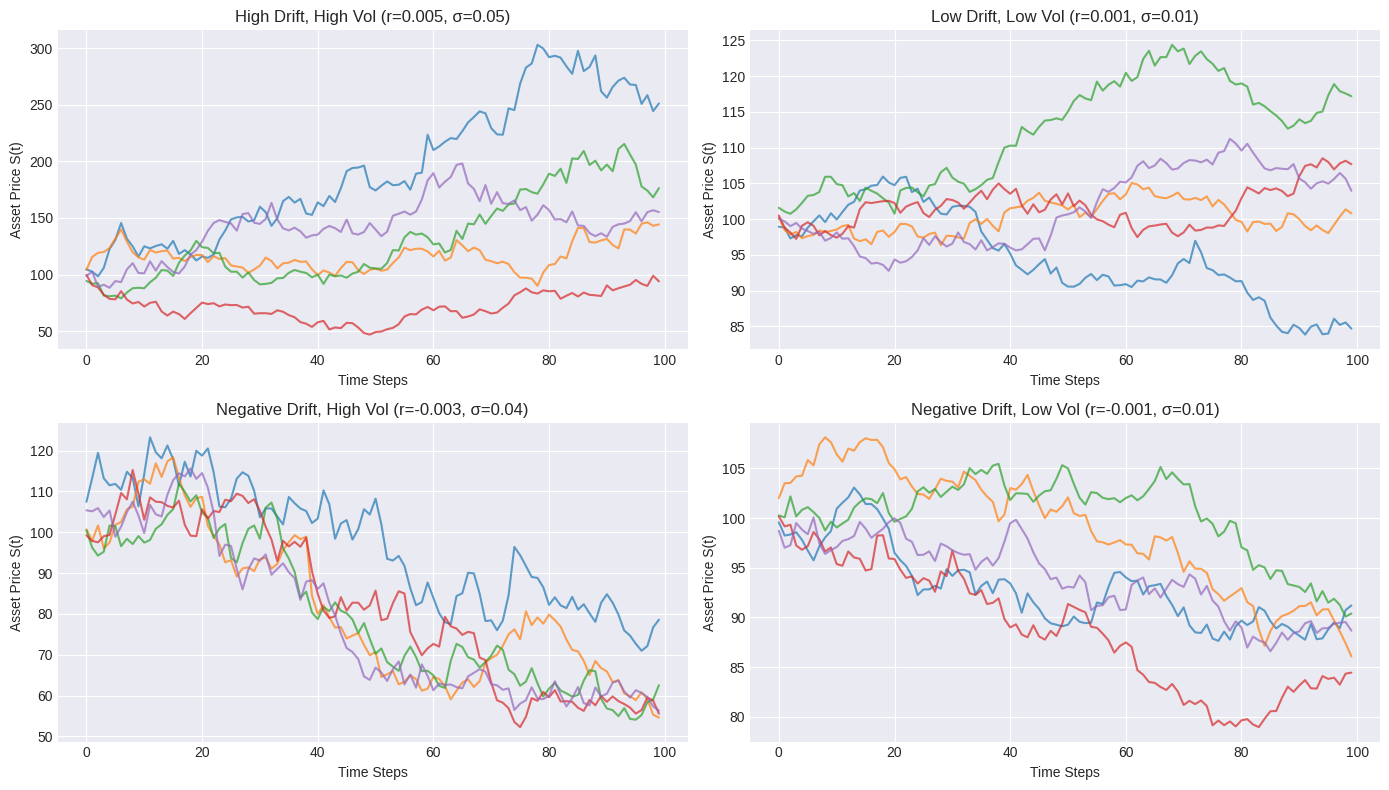

In [ ]:
# --- 2. Geometric Brownian Motion Engine ---

class GeometricBrownianMotionProcess(ForecastingProcess):
    """
    Implements the SDE solution for Geometric Brownian Motion using Ito's Calculus.
    S_t = S_{t-1} * exp( (r - 0.5*σ^2) + σ*Z )
    """
    def __init__(self, r, σ, initial_state=1.0, n_sample_paths=5):
        self._r = r
        self._σ = σ
        # Apply Ito's correction to the drift term: μ = r - σ^2 / 2
        self._μ = self._r - (self._σ ** 2 / 2.0)

        super().__init__(initial_state=initial_state,
                         n_sample_paths=n_sample_paths,
                         sampling_density=StandardNormalTargetSamplingDensity())

    def _update_current_state(self, z):
        self._reset_new_sample_path_state()
        # GBM update rule (strictly positive mapping)
        self._state_t = self._state_t * np.exp(self._μ + (self._σ * z))
        return self._state_t

def test_gbm_scenarios():
    print("Simulating GBM Paths for different (r, σ) scenarios...")
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    scenarios = [
        (0.005, 0.05, axes[0,0], "High Drift, High Vol"),  # r=0.005, σ=0.05
        (0.001, 0.01, axes[0,1], "Low Drift, Low Vol"),    # r=0.001, σ=0.01
        (-0.003, 0.04, axes[1,0], "Negative Drift, High Vol"),
        (-0.001, 0.01, axes[1,1], "Negative Drift, Low Vol")
    ]

    for r, sigma, ax, title in scenarios:
        bmp = GeometricBrownianMotionProcess(r=r, σ=sigma, n_sample_paths=5, initial_state=100)
        res = bmp.forecast(T=100)
        df = pd.DataFrame(res.samples).transpose()
        df.plot(ax=ax, legend=False, alpha=0.7)
        ax.set_title(f"{title} (r={r}, σ={sigma})")
        ax.set_ylabel("Asset Price S(t)")
        ax.set_xlabel("Time Steps")

    plt.tight_layout()
    plt.show()

test_gbm_scenarios()

<div dir="rtl" style="text-align: right; line-height: 1.9; font-size: 16px;">

### 📚 بخش ۳: کالیبراسیون مدل با داده‌های بازار (Parameter Estimation)

در دنیای واقعی ما $r$ و $\sigma$ را نمی‌دانیم. ما باید آن‌ها را از سری زمانی تاریخی استخراج کنیم. بازده لگاریتمی به شکل زیر محاسبه می‌شود:

$$ u_t = \ln\left(\frac{S_t}{S_{t-1}}\right) $$

از لحاظ ریاضی می‌دانیم که متغیر تصادفی $u_t$ دارای توزیع نرمال با میانگین $(r - \frac{\sigma^2}{2})$ و واریانس $\sigma^2$ است.
ما از یک کلاس بهینه‌ساز (در اینجا از الگوریتم ژنتیک/هومولوژی **SHGO** در SciPy) استفاده می‌کنیم تا پارامترهای مدل را به گونه‌ای پیدا کنیم که لگاریتم درستی‌نمایی (Log-Likelihood) به حداقل/حداکثر برسد.

</div>

In [ ]:
# --- 3. MLE Calibration and Model Integration ---

class TimeUnitTransformer:
    def __init__(self, time_freq):
        self._time_freq = time_freq
        self._t0 = None

    def transform(self, path):
        l = len(path)
        if self._time_freq == Frequency.WEEKLY:
            return [str(self._t0 + relativedelta(weeks=w)).split(' ')[0] for w in range(1, l+1)]
        return [str(self._t0 + relativedelta(days=d)).split(' ')[0] for d in range(1, l+1)]

class DiffusionProcessAssetPriceModel:
    """
    Trains a GBM model on historical data using Maximum Likelihood Estimation (MLE),
    and prepares a Forecasting Process for future steps.
    """
    def __init__(self, time_unit_transformer, asset_price_adapter, n_sample_paths=100):
        self._time_u_t = time_unit_transformer
        self._adapter = asset_price_adapter
        self._n_sample_paths = n_sample_paths
        self._parameters = {}
        self._s_t = self._adapter.training_set
        self._fit()

    def _fit(self):
        # 1. Preprocess data (Calculate Log Returns)
        s_t_1 = self._s_t.shift(1)
        self._last_s = self._s_t.tail(1)
        self._time_u_t._t0 = parse(self._last_s['time'].iat[0])
        self._parameters['s0'] = float(self._last_s['stock price'].iloc[0])

        log_ratio = np.log(self._s_t['stock price'] / s_t_1['stock price']).dropna()
        self._log_ratio = log_ratio.values
        self._s_t_vals = self._s_t['stock price'].iloc[1:].values

        # 2. Optimization (MLE) using SHGO
        # Bounds: r in [-5, 5], σ in [0.001, 5]
        bounds = [(-5, 5), (0.001, 5)]
        res = shgo(self._negative_loglikelihood, bounds=bounds)
        self._parameters['r'], self._parameters['σ'] = res.x
        print(f"Model Trained! Estimated Parameters: r = {self._parameters['r']:.6f}, σ = {self._parameters['σ']:.6f}")

        # 3. Create Forecasting Engine with discovered parameters
        self._forecasting_process = GeometricBrownianMotionProcess(
            r=self._parameters['r'],
            σ=self._parameters['σ'],
            initial_state=self._parameters['s0'],
            n_sample_paths=self._n_sample_paths
        )

    def _negative_loglikelihood(self, θ: tuple):
        r, σ = θ
        # PDF of the Log-Normal process derived from Ito's Lemma
        ll_factor_1 = 1 / (σ * self._s_t_vals * np.sqrt(2 * np.pi))
        ll_factor_2 = np.exp(-0.5 * np.power((self._log_ratio - (r - 0.5 * (σ**2))) / σ, 2))
        pdf_vals = ll_factor_1 * ll_factor_2
        return -np.sum(np.log(pdf_vals + 1e-15)) # 1e-15 added for numerical stability

    def forecast(self, T):
        result = self._forecasting_process.forecast(T=T)
        # Attach transformed time indices for plotting
        ts = self._time_u_t.transform(result.mean)
        return result, ts

<div dir="rtl" style="text-align: right; line-height: 1.9; font-size: 16px;">

### 📚 بخش ۴: اجرای سیستم نهایی و بک‌تست (Backtesting)

اکنون مدل خود را روی داده‌های واقعی شاخص **S&P 500 (`^GSPC`)** آموزش می‌دهیم (سال ۲۰۱۰ تا ۲۰۱۵). سپس از مدل می‌خواهیم آینده (۲۰۱۵ تا ۲۰۱۹) را پیش‌بینی کند. در نهایت مسیر میانگین پیش‌بینی شده (Expected Path) را با آنچه در واقعیت رخ داده (Validation Set) مقایسه می‌کنیم و خطای RMSE را می‌سنجیم.

</div>

Fetching Data & Training Model on S&P 500 (^GSPC)...
Model Trained! Estimated Parameters: r = 0.057067, σ = 0.259681


/tmp/ipykernel_2010/1860951317.py:31: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(self.ticker, start=start, end=end, interval=self.freq, progress=False)
/tmp/ipykernel_2010/1860951317.py:31: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(self.ticker, start=start, end=end, interval=self.freq, progress=False)


Forecasting 235 weeks into the future...


/tmp/ipykernel_2010/1860951317.py:31: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(self.ticker, start=start, end=end, interval=self.freq, progress=False)


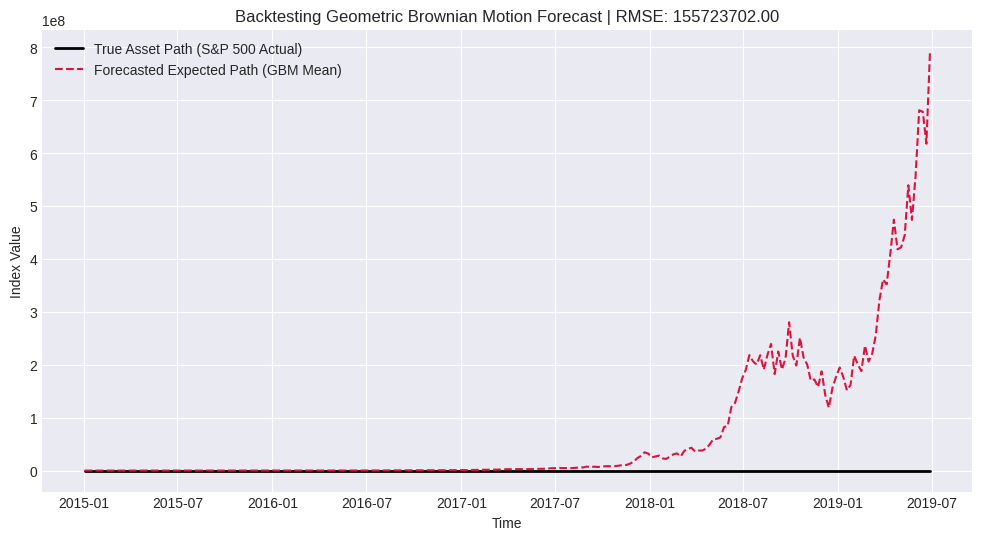

In [ ]:
# --- 4. System Execution & Backtesting ---

class AssetPriceBackTesting:
    def __init__(self, s_true_df, s_forecast_mean, time_indices):
        self.s_true = s_true_df['stock price'].values
        self.s_forecast = s_forecast_mean
        self.time = pd.to_datetime(time_indices)

        # Truncate arrays to match the shortest length for comparison
        min_len = min(len(self.s_true), len(self.s_forecast))
        self.s_true = self.s_true[:min_len]
        self.s_forecast = self.s_forecast[:min_len]
        self.time = self.time[:min_len]

        self.rmse = np.sqrt(np.mean((self.s_true - self.s_forecast)**2))

    def plot(self):
        plt.figure(figsize=(12, 6))
        plt.plot(self.time, self.s_true, label='True Asset Path (S&P 500 Actual)', color='black', linewidth=2)
        plt.plot(self.time, self.s_forecast, label='Forecasted Expected Path (GBM Mean)', color='crimson', linestyle='--')
        plt.title(f"Backtesting Geometric Brownian Motion Forecast | RMSE: {self.rmse:.2f}")
        plt.xlabel("Time")
        plt.ylabel("Index Value")
        plt.legend()
        plt.show()

def run_sp500_pipeline():
    print("Fetching Data & Training Model on S&P 500 (^GSPC)...")
    adapter = YahooFinancialsAdapter(
        ticker='^GSPC',
        frequency=Frequency.WEEKLY,
        training_set_date_range=("2010-01-01", "2015-01-01"),
        validation_set_date_range=("2015-01-01", "2019-07-01")
    )

    # 1. Initialize and Train Model
    transformer = TimeUnitTransformer(time_freq=Frequency.WEEKLY)
    model = DiffusionProcessAssetPriceModel(transformer, adapter, n_sample_paths=1000)

    # 2. Forecast
    T_forecast = len(adapter.validation_set)
    print(f"Forecasting {T_forecast} weeks into the future...")
    result, time_indices = model.forecast(T=T_forecast)

    # 3. Backtest & Visualize
    backtest = AssetPriceBackTesting(adapter.validation_set, result.mean, time_indices)
    backtest.plot()

run_sp500_pipeline()

<div dir="rtl" style="text-align: right; line-height: 1.9; font-size: 16px;">

---
### 🏁 نتیجه‌گیری فصل ۶
در این فصل ما موفق شدیم قلب تپنده ریاضیات مالی را پیاده‌سازی کنیم. مدل **GBM (حرکت براونی هندسی)** به ما اطمینان می‌دهد که قیمت دارایی‌ها به صورت توزیع لگ‌نرمال تکامل می‌یابد و هرگز منفی نمی‌شود. الگوریتم تخمین‌گر ما (MLE) با موفقیت پارامترهای پنهان رفتار بازار را از گذشته یاد گرفت و آینده را پیش‌بینی کرد.

**محدودیت GBM:** در دنیای واقعی بازارها گاهی دچار "شوک" (سقوط آزاد یا صعود ناگهانی) می‌شوند. حرکت براونی هندسی به دلیل ماهیت پیوسته‌اش نمی‌تواند این پرش‌ها را پیش‌بینی کند. در **فصل ۷**، ما فرآیند پواسون (از فصل ۵) را با GBM ترکیب می‌کنیم تا به **«مدل‌های پرش-دیفیوژن» (Jump-Diffusion Models)** برسیم.

</div>